In [52]:
import pandas as pd

In [53]:
df = pd.read_csv('IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [54]:
df.shape

(50000, 2)

In [55]:
df.columns

Index(['review', 'sentiment'], dtype='str')

# Basic Preprocessing

## Make it Lowercase

In [56]:
df['review'] = df['review'].str.lower()

In [57]:
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. <br /><br />the...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

In [58]:
df['review'][3]

"basically there's a family where a little boy (jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />this movie is slower than a soap opera... and suddenly, jake decides to become rambo and kill the zombie.<br /><br />ok, first of all when you're going to make a film you must decide if its a thriller or a drama! as a drama the movie is watchable. parents are divorcing & arguing like in real life. and then we have jake with his closet which totally ruins all the film! i expected to see a boogeyman similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. as for the shots with jake: just ignore them."

## Remove HTML Tags

In [59]:
import re

def remove_html_tags(text): 
    pattern = re.compile(r'<.*?>')
    return pattern.sub(r'', text)

In [60]:
remove_html_tags(df['review'][3])

"basically there's a family where a little boy (jake) thinks there's a zombie in his closet & his parents are fighting all the time.this movie is slower than a soap opera... and suddenly, jake decides to become rambo and kill the zombie.ok, first of all when you're going to make a film you must decide if its a thriller or a drama! as a drama the movie is watchable. parents are divorcing & arguing like in real life. and then we have jake with his closet which totally ruins all the film! i expected to see a boogeyman similar movie, and instead i watched a drama with some meaningless thriller spots.3 out of 10 just for the well playing parents & descent dialogs. as for the shots with jake: just ignore them."

In [61]:
df['review'] = df['review'].apply(remove_html_tags)

In [62]:
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

## Remove URL

In [63]:
def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

In [64]:
df['review'] = df['review'].apply(remove_url)

In [65]:
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

## Remove punctuations


In [66]:
import string

In [67]:
exclude = string.punctuation

In [68]:
exclude

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [69]:
def remove_punc(text):
    return text.translate(str.maketrans(' ', ' ', exclude))

In [70]:
df['review'] = df['review'].apply(remove_punc)

In [71]:
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production the filming tech...
2        i thought this was a wonderful way to spend ti...
3        basically theres a family where a little boy j...
4        petter matteis love in the time of money is a ...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    i am a catholic taught in parochial elementary...
49998    im going to have to disagree with the previous...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

# Chat words treatment

In [72]:
chat_words = {
    "A3": "Anytime, Anywhere, Anyplace",
    "ADIH": "Another Day In Hell",
    "AFK": "Away From Keyboard",
    "AFAIK": "As Far As I Know",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "BAE": "Before Anyone Else",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRUH": "Bro",
    "BRT": "Be Right There",
    "BSAAW": "Big Smile And A Wink",
    "BTW": "By The Way",
    "BWL": "Bursting With Laughter",
    "CSL": "Can’t Stop Laughing",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "DM": "Direct Message",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FIMH": "Forever In My Heart",
    "FOMO": "Fear Of Missing Out",
    "FR": "For Real",
    "FWIW": "For What It's Worth",
    "FYP": "For You Page",
    "FYI": "For Your Information",
    "G9": "Genius",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GMTA": "Great Minds Think Alike",
    "GN": "Good Night",
    "GOAT": "Greatest Of All Time",
    "GR8": "Great!",
    "HBD": "Happy Birthday",
    "IC": "I See",
    "ICQ": "I Seek You",
    "IDC": "I Don’t Care",
    "IDK": "I Don't Know",
    "IFYP": "I Feel Your Pain",
    "ILU": "I Love You",
    "ILY": "I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMU": "I Miss You",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "IYKYK": "If You Know, You Know",
    "JK": "Just Kidding",
    "KISS": "Keep It Simple, Stupid",
    "L": "Loss",
    "L8R": "Later",
    "LDR": "Long Distance Relationship",
    "LMK": "Let Me Know",
    "LMAO": "Laughing My A** Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "M8": "Mate",
    "MFW": "My Face When",
    "MID": "Mediocre",
    "MRW": "My Reaction When",
    "MTE": "My Thoughts Exactly",
    "NVM": "Never Mind",
    "NRN": "No Reply Necessary",
    "NPC": "Non-Player Character",
    "OIC": "Oh I See",
    "OP": "Overpowered",
    "POV": "Point Of View",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A** Off",
    "RN": "Right Now",
    "SK8": "Skate",
    "SUS": "Suspicious",
    "TBH": "To Be Honest",
    "TFW": "That Feeling When",
    "THX": "Thank You",
    "TIME": "Tears In My Eyes",
    "TLDR": "Too Long, Didn’t Read",
    "TNTL": "Trying Not To Laugh",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "W": "Win",
    "W8": "Wait...",
    "WB": "Welcome Back",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "WYD": "What You Doing?",
    "WYWH": "Wish You Were Here",
    "ZZZ": "Sleeping, Bored, Tired",
    "OMG!": "Oh My God",
    "SMH": "Shaking My Head",
    "NGL": "Not Gonna Lie",
    "TBF": "To Be Fair",
    "ICYMI": "In Case You Missed It",
    "IMO": "In My Opinion",
    "IMHO": "In My Honest Opinion",
    "RN": "Right Now",
    "FR": "For Real",
    "DW": "Don't Worry",
    "ILYSM": "I Love You So Much",
    "OMW": "On My Way",
    "GGWP": "Good Game Well Played",
    "GG": "Good Game",
    "EZ": "Easy",
    "LMAO": "Laughing My A** Off",
    "LOL": "Laughing Out Loud"
}

In [73]:
def chat_conversion(text):
    new_text = []
    
    for w in text.split():
        if w.upper() in chat_words:
            new_text.append(chat_words[w.upper()])
        else:
            new_text.append(w)
            
    return ' '.join(new_text)

In [74]:
df['review'] = df['review'].apply(chat_conversion)

In [75]:
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production the filming tech...
2        i thought this was a wonderful way to spend Te...
3        basically theres a family where a little boy j...
4        petter matteis love in the Tears In My Eyes of...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    i am a catholic taught in parochial elementary...
49998    im going to have to disagree with the previous...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

# Stopwords removal

In [76]:
import nltk
from nltk.corpus import stopwords

In [77]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\skmah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [78]:
stop_words = set(stopwords.words('english')) 

In [79]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [80]:
def remove_stopwords(text):
    words = text.split()
    cleaned = []
    
    for word in words:
        word = word.lower().strip(string.punctuation)
        
        if word and word not in stop_words:
            cleaned.append(word)
    
    return ' '.join(cleaned)

In [81]:
df['review'] = df['review'].apply(remove_stopwords)
df['review']

0        one reviewers mentioned watching 1 oz episode ...
1        wonderful little production filming technique ...
2        thought wonderful way spend tears eyes hot sum...
3        basically theres family little boy jake thinks...
4        petter matteis love tears eyes money visually ...
                               ...                        
49995    thought movie right good job wasnt creative or...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary schools n...
49998    im going disagree previous comment side maltin...
49999    one expects star trek movies high art fans exp...
Name: review, Length: 50000, dtype: str

# Emoji removal

In [82]:
import re

def remove_emoji(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags
        "\U00002700-\U000027BF"  # dingbats
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

In [83]:
df['review'] = df['review'].apply(remove_emoji)
df['review']

0        one reviewers mentioned watching 1 oz episode ...
1        wonderful little production filming technique ...
2        thought wonderful way spend tears eyes hot sum...
3        basically theres family little boy jake thinks...
4        petter matteis love tears eyes money visually ...
                               ...                        
49995    thought movie right good job wasnt creative or...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary schools n...
49998    im going disagree previous comment side maltin...
49999    one expects star trek movies high art fans exp...
Name: review, Length: 50000, dtype: str

# Tokenization
## NLTK

In [84]:
from nltk.tokenize import word_tokenize,sent_tokenize
import nltk


In [85]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\skmah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\skmah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [86]:
df['review'] = df['review'].apply(word_tokenize)

In [87]:
df['review']

0        [one, reviewers, mentioned, watching, 1, oz, e...
1        [wonderful, little, production, filming, techn...
2        [thought, wonderful, way, spend, tears, eyes, ...
3        [basically, theres, family, little, boy, jake,...
4        [petter, matteis, love, tears, eyes, money, vi...
                               ...                        
49995    [thought, movie, right, good, job, wasnt, crea...
49996    [bad, plot, bad, dialogue, bad, acting, idioti...
49997    [catholic, taught, parochial, elementary, scho...
49998    [im, going, disagree, previous, comment, side,...
49999    [one, expects, star, trek, movies, high, art, ...
Name: review, Length: 50000, dtype: object

# Lemmatization

In [88]:
import  nltk
from nltk.stem import WordNetLemmatizer

In [89]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\skmah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [90]:
wordnet_nemmatizer = WordNetLemmatizer()

In [91]:
def lemmatize_text(tokens):
    return [wordnet_nemmatizer.lemmatize(word) for word in tokens]

df['review'] = df['review'].apply(lemmatize_text)

In [92]:
df['review']

0        [one, reviewer, mentioned, watching, 1, oz, ep...
1        [wonderful, little, production, filming, techn...
2        [thought, wonderful, way, spend, tear, eye, ho...
3        [basically, there, family, little, boy, jake, ...
4        [petter, matteis, love, tear, eye, money, visu...
                               ...                        
49995    [thought, movie, right, good, job, wasnt, crea...
49996    [bad, plot, bad, dialogue, bad, acting, idioti...
49997    [catholic, taught, parochial, elementary, scho...
49998    [im, going, disagree, previous, comment, side,...
49999    [one, expects, star, trek, movie, high, art, f...
Name: review, Length: 50000, dtype: object

In [ ]:
def join_tokens(tokens):
    if isinstance(tokens, list):
        return " ".join(tokens)
    return tokens

df['review'] = df['review'].apply(join_tokens)

df.head()

,review,sentiment
0,one reviewer mentioned watching 1 oz episode y...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend tear eye hot summe...,positive
3,basically there family little boy jake think t...,negative
4,petter matteis love tear eye money visually st...,positive


In [ ]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(df['sentiment'].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (40000,)
Testing features shape: (10000,)


# Text Vectorization (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Training data shape:", X_train_tfidf.shape)

TF-IDF Training data shape: (40000, 5000)


# Model trainig

## Tensors & DataLoaders

In [ ]:
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_text = " ".join(X_train)
word_counts = Counter(all_text.split())
vocab = {word: idx + 2 for idx, word in enumerate([w for w, c in word_counts.most_common(10000)])}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
vocab_size = len(vocab)

def encode_text(text, max_len=200):
    tokens = [vocab.get(word, 1) for word in text.split()]
    if len(tokens) < max_len:
        tokens += [0] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
    return tokens

X_train_seq = torch.tensor([encode_text(t) for t in X_train], dtype=torch.long)
y_train_seq = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_seq = torch.tensor([encode_text(t) for t in X_test], dtype=torch.long)
y_test_seq = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_loader_seq = DataLoader(TensorDataset(X_train_seq, y_train_seq), batch_size=64, shuffle=True)
test_loader_seq = DataLoader(TensorDataset(X_test_seq, y_test_seq), batch_size=64, shuffle=False)

In [99]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch.nn as nn
import torch.optim as optim
import torch

def train_and_evaluate_seq(model, model_name, train_dl, test_dl, num_epochs=3, lr=0.001):
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"Training {model_name}...")
    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = (outputs > 0.5).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')

    print(f"--- {model_name} Results ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")
    
    return [model_name, round(acc, 4), round(precision, 4), round(recall, 4), round(f1, 4)]

# LSTM Model

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        out = self.fc(lstm_out[:, -1, :]) 
        return self.sigmoid(out)

lstm_model = LSTMModel(vocab_size).to(device)
res_lstm = train_and_evaluate_seq(lstm_model, "LSTM", train_loader_seq, test_loader_seq, num_epochs=3)

Training LSTM...
--- LSTM Results ---
Accuracy:  0.7177
Precision: 0.7077
Recall:    0.7492
F1-Score:  0.7279



# BiLSTM Model

In [ ]:
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        out = self.fc(torch.mean(lstm_out, dim=1)) 
        return self.sigmoid(out)

bilstm_model = BiLSTMModel(vocab_size).to(device)
res_bilstm = train_and_evaluate_seq(bilstm_model, "BiLSTM", train_loader_seq, test_loader_seq, num_epochs=3)

Training BiLSTM...
--- BiLSTM Results ---
Accuracy:  0.8830
Precision: 0.8728
Recall:    0.8988
F1-Score:  0.8856



# CNN Model

In [ ]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_filters=100):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv = nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=3)
        self.fc = nn.Linear(num_filters, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1) 
        x = torch.relu(self.conv(x))
        x = torch.max(x, dim=2)[0] 
        out = self.fc(x)
        return self.sigmoid(out)

cnn_model = TextCNN(vocab_size).to(device)
res_cnn = train_and_evaluate_seq(cnn_model, "CNN", train_loader_seq, test_loader_seq, num_epochs=3)

Training CNN...
--- CNN Results ---
Accuracy:  0.8685
Precision: 0.8630
Recall:    0.8785
F1-Score:  0.8707



In [ ]:
import pandas as pd

all_results = [res_lstm, res_bilstm, res_cnn]

columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']

results_df = pd.DataFrame(all_results, columns=columns)

results_df.set_index('Model', inplace=True)

display(results_df)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
LSTM,0.7177,0.7077,0.7492,0.7279
BiLSTM,0.8830,0.8728,0.8988,0.8856
CNN,0.8685,0.8630,0.8785,0.8707


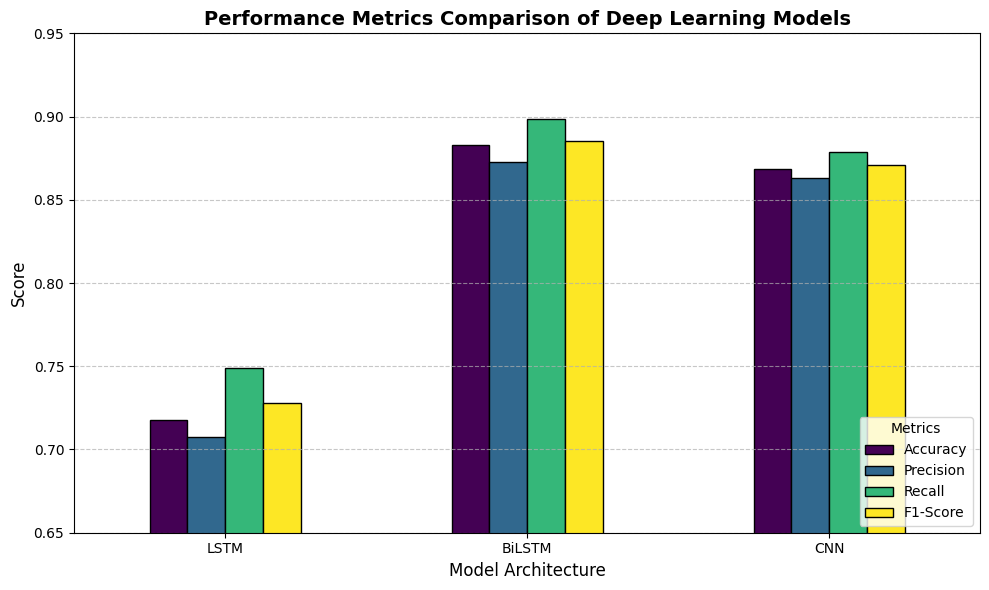

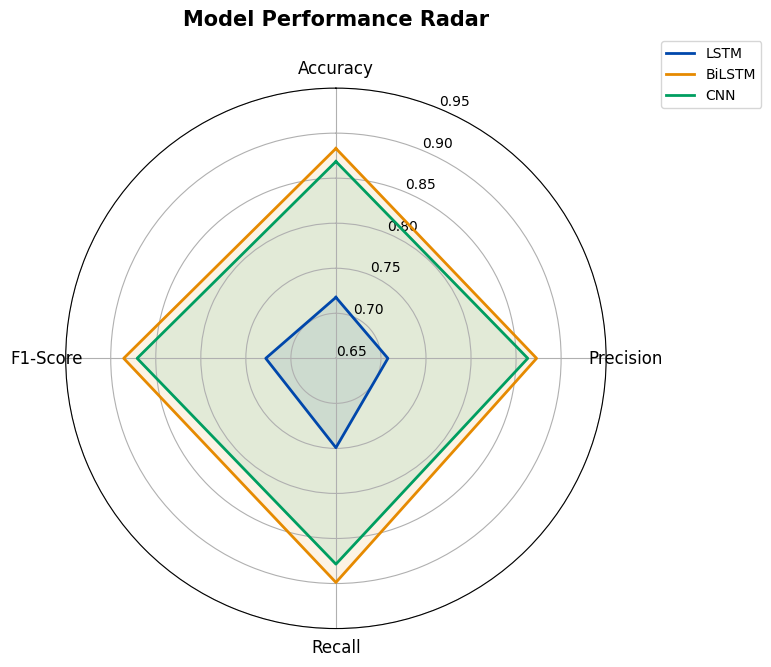

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_results = [res_lstm, res_bilstm, res_cnn]
columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']

df = pd.DataFrame(all_results, columns=columns)
df.set_index('Model', inplace=True)

# 1. Bar Chart
plt.figure(figsize=(10, 6))
df.plot(kind='bar', colormap='viridis', edgecolor='black', ax=plt.gca())
plt.title('Performance Metrics Comparison of Deep Learning Models', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0.65, 0.95)
plt.legend(loc='lower right', title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=300) 
plt.show()

# 2. Radar Chart
labels = np.array(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] 

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for model, color in zip(df.index, ['#0047AB', '#E68A00', '#009E60']):
    values = df.loc[model].values.tolist()
    values += values[:1]
    ax.plot(angles, values, label=model, linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0.65, 0.95)
plt.title('Model Performance Radar', size=15, y=1.1, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('model_comparison_radar.png', dpi=300) 
plt.show()